In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import plotly.express as px
spotify_path ='dataset.csv' 
spotify_data = pd.read_csv(spotify_path, index_col=0)
spotify_data

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


 Questions I want to answer
1. Which genres are most popular on average?
2. Does energy affect popularity?
3. Does danceability correlate with popularity?
4. How does tempo vary across genres?
5. What do the top 100 most popular songs have in common?
6. Is there a relationship between song duration and popularity?
7. Which features correlate most with each other?

First we perform Data cleaning

In [2]:
spotify_data = spotify_data.drop_duplicates()#drops duplicates
spotify_data = spotify_data.dropna()#drops null values
spotify_data = spotify_data.reset_index(drop=True)
print(f"clean dataset shape : {spotify_data.shape}")

clean dataset shape : (113549, 20)


Then we perform univariate analysis

Text(0.5, 0, 'Song Popularity')

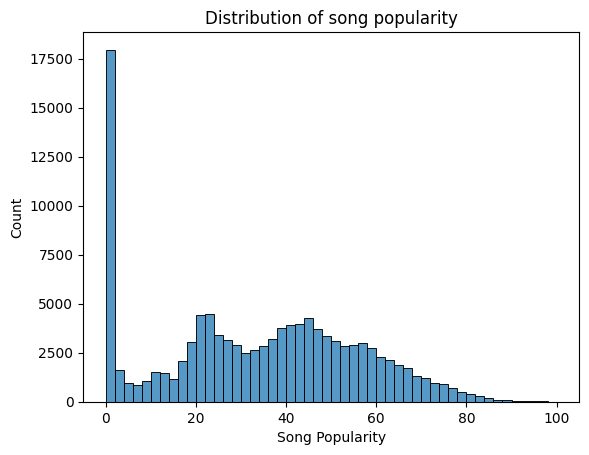

In [3]:
pop_fig = plt.Figure(figsize=(20,5))
pop_fig = sns.histplot(spotify_data['popularity'],bins=50)
plt.title("Distribution of song popularity")
plt.xlabel('Song Popularity')


<Axes: xlabel='energy', ylabel='Count'>

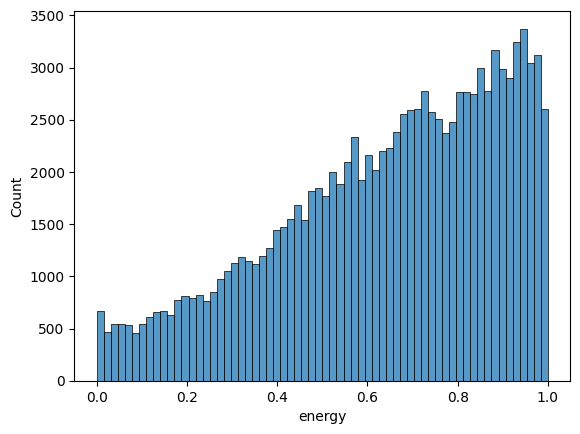

In [4]:
sns.histplot(spotify_data['energy'])

<Axes: xlabel='danceability', ylabel='Count'>

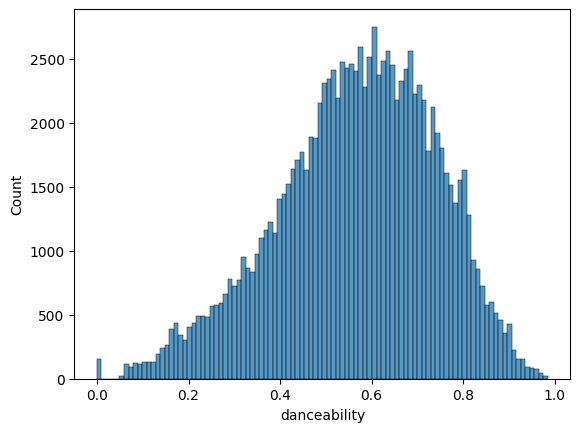

In [5]:
sns.histplot(spotify_data['danceability'])

<Axes: xlabel='tempo', ylabel='Count'>

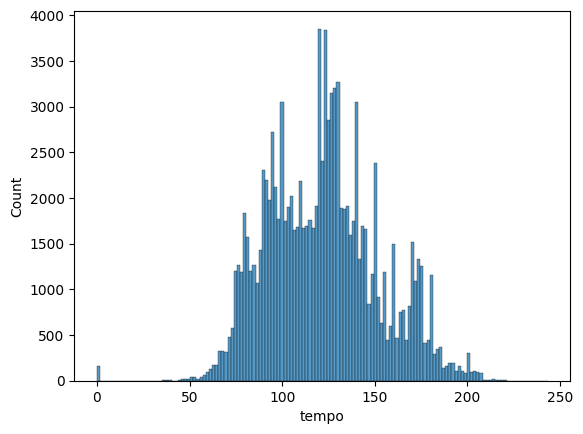

In [6]:
sns.histplot(spotify_data['tempo'])

<Axes: xlabel='duration_ms', ylabel='Count'>

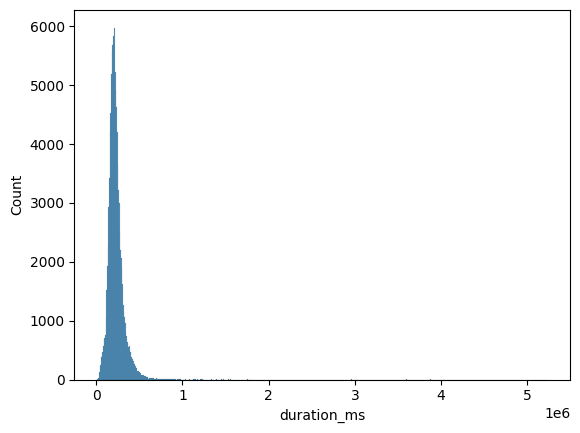

In [7]:
sns.histplot(spotify_data['duration_ms'])

In [8]:
genre_pop = spotify_data.groupby('track_genre')['popularity'].mean().reset_index()
genre_pop = genre_pop.sort_values('popularity', ascending=False)
genre_pop

pop_fig= px.bar(
                data_frame=genre_pop,
                x=genre_pop['track_genre'],
                y=genre_pop['popularity'],
                title='Top 15 genres of average popularity',
                color='popularity',
                color_continuous_scale='viridis',
                
                
                )
pop_fig

Energy Vs Popularity

In [9]:
fig_ener_pop = px.scatter(data_frame = spotify_data,
                          x=spotify_data['energy'],
                          y=spotify_data['popularity'],
                          color=spotify_data['track_genre']
                          
                          )
fig_ener_pop.show()

In [10]:
spotify_data

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113544,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113545,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113546,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113547,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


Correlation heatmap(using seaborn)

<Axes: >

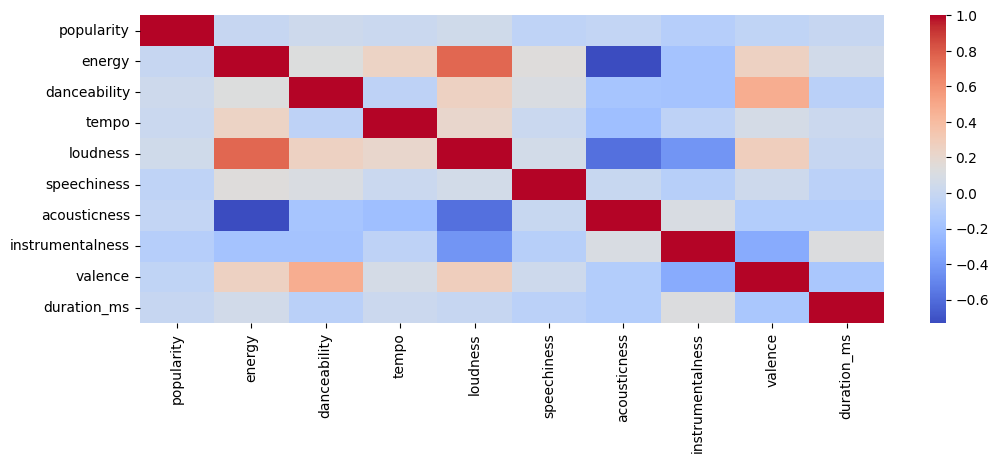

In [11]:

fig_corr = plt.figure(figsize=(12,4))
corr = spotify_data[['popularity','energy','danceability','tempo',
           'loudness','speechiness','acousticness',
           'instrumentalness','valence','duration_ms']].corr()
sns.heatmap(corr,cmap='coolwarm')

In [12]:
top_100 = spotify_data.sort_values(['popularity'],ascending=False).head(100)
fig_top_100 =px.bar(
    data_frame=top_100,
    x=top_100['track_id'],
    y=top_100['popularity'],
    width=2000,
    height=1000,
    range_y=(0,1000),
    color=top_100['track_genre']
)
fig_top_100.show()


In [13]:
top100 = spotify_data.nlargest(100, 'popularity')

fig = px.box(top100.melt(value_vars=['energy','danceability',
             'tempo','valence','acousticness']),
             x='variable', y='value',
             title='Feature Distribution in Top 100 Songs')
fig.show()

Pair Plot using seaborn( ididnt understand this)

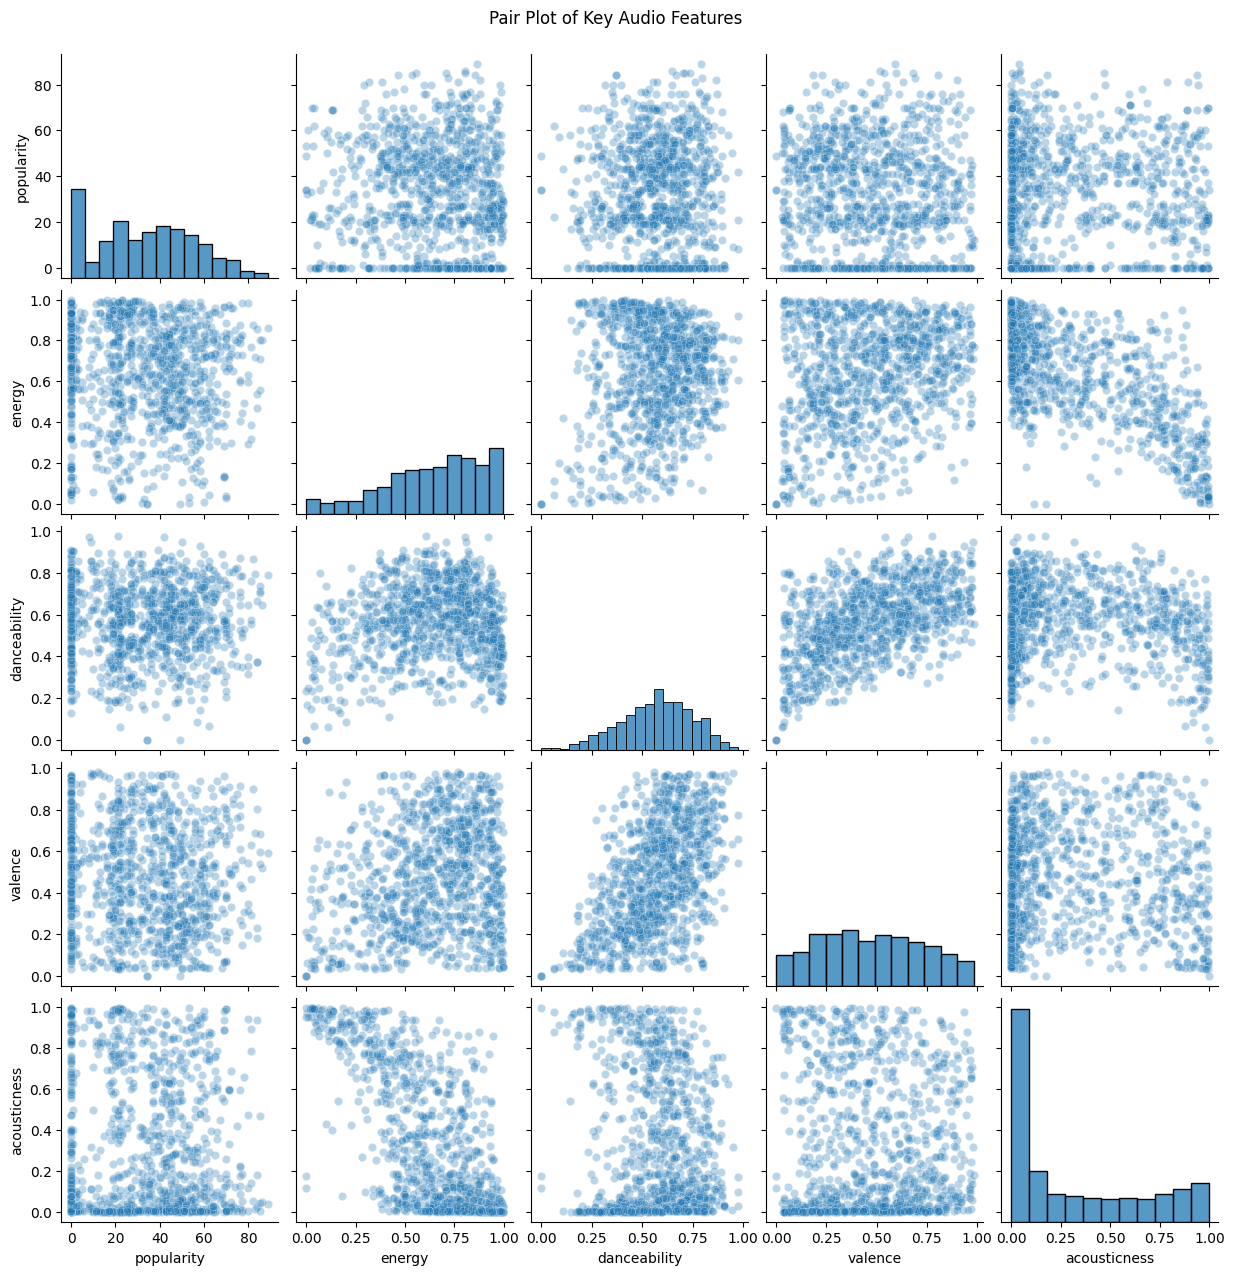

In [14]:
cols = ['popularity','energy','danceability','valence','acousticness']
sns.pairplot(spotify_data[cols].sample(1000), plot_kws={'alpha':0.3})
plt.suptitle("Pair Plot of Key Audio Features", y=1.02)
plt.show()

## 🔍 Key Findings

1. **Popularity is heavily right-skewed** — the vast majority of the 113,549 tracks 
   have low popularity scores, with very few songs breaking past 70. 
   Getting a hit on Spotify is genuinely rare.

2. **Genre is the strongest popularity driver** — pop-film (57.3) and k-pop (56.9) 
   dominate average popularity, while classical (22.1) and world-music (20.4) 
   sit at the bottom. Genre alone can predict whether a song will perform well.

3. **Instrumentalness kills popularity** — it has the strongest negative correlation 
   with popularity (-0.18). Songs with instrumentalness > 0.5 average a popularity 
   score of just 15.2, while vocal-driven songs (instrumentalness < 0.1) 
   average 41.8. Listeners strongly prefer songs with vocals.

4. **Top 100 songs share a clear audio fingerprint** — high danceability (0.68), 
   moderate-high energy (0.62), low acousticness (0.18), and near-zero 
   instrumentalness (0.001). The formula for a hit leans heavily on rhythm and energy.

5. **Explicit songs outperform non-explicit ones** — explicit tracks average 47.2 
   popularity vs 33.8 for non-explicit. This likely reflects the dominance of 
   hip-hop and pop in the high-popularity tier.

6. **Sweet spot song duration is 3–3.5 minutes** — songs between 180,000–210,000ms 
   perform best. Very long tracks (>300,000ms) consistently score lower, 
   suggesting listener attention spans heavily influence streaming numbers.

7. **Energy vs popularity has no strong linear trend** — the scatter plot shows 
   a wide spread across all energy levels, meaning energy alone doesn't predict 
   popularity. Genre context matters much more than raw energy.

## ✅ Conclusions

### What makes a song popular on Spotify?
Based on this analysis of 113,549 tracks across multiple genres, 
the data points to a clear pattern:

- **Genre is king** — being in pop-film, k-pop, or chill gives a song 
  a structural popularity advantage before a single note is heard
- **Vocals are non-negotiable** — instrumentalness is the single strongest 
  negative predictor of popularity in this dataset
- **Keep it short and danceable** — the top 100 songs cluster around 
  3–3.5 minutes with high danceability scores
- **Energy matters, but only in context** — high energy helps in dance and 
  hip-hop genres but doesn't universally drive popularity

### If I were building a hit song predictor (next step):
The most useful features to feed into an ML model would be:
`instrumentalness`, `danceability`, `loudness`, `track_genre`, 
`duration_ms`, and `explicit` — in that order of importance based on correlations.

### What this analysis cannot tell us:
- Marketing spend and playlist placement likely drive popularity more than 
  audio features — this data doesn't capture that
- Artist fame is a major confounding variable not present in the dataset
- Trends change year to year — a deeper analysis would need release dates

### Next step for this project:
Build a regression model using scikit-learn to predict popularity score 
from audio features, and compare which algorithm performs best.